# 1. Import library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ExpSineSquared, DotProduct
from sklearn.gaussian_process import GaussianProcessClassifier, GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, WhiteKernel, ConstantKernel
from skopt import gp_minimize
from skopt.space import Real
from scipy.optimize import differential_evolution
from scipy.optimize import minimize
from scipy.stats import norm

# 2. Data Inputs

In [2]:
inputs2 = np.array([[0.66579958, 0.12396913],
       [0.87779099, 0.7786275 ],
       [0.14269907, 0.34900513],
       [0.84527543, 0.71112027],
       [0.45464714, 0.29045518],
       [0.57771284, 0.77197318],
       [0.43816606, 0.68501826],
       [0.34174959, 0.02869772],
       [0.33864816, 0.21386725],
       [0.70263656, 0.9265642 ],
       [0.727272, 0.939393],
       [0.840803, 0.130818],
       [0.691269, 0.924740],
       [0.797595, 0.931864],
       [0.715430, 0.917836],
       [0.707415, 0.937876],
       [0.705411, 0.951904],
       [0.710453, 0.937894],
       [0.696278, 0.945170],
       [0.694576, 0.945798],
       [0.697674, 0.945736]])

X = inputs2

# 3. Data Outputs

In [3]:
outputs2 = np.array([ 0.53899612,  0.42058624, -0.06562362,  0.29399291,  0.21496451,
        0.02310555,  0.24461934,  0.03874902, -0.01385762,  0.61120522, 0.507049598072218, 
        0.2627386914961054, 0.48461365245218785, 0.014073924510516311,
        0.5915925565120062, 0.6634549579583637, 0.6213741846004396, 0.631305117880453, 
        0.749200613484932, 0.6275915699437626, 0.5640562817980392])

y = outputs2

# 4. Visualization

## 4.1 Visualization of outputs trend

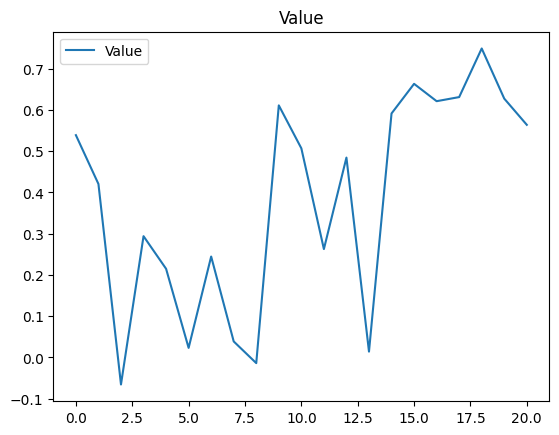

In [4]:
df = pd.DataFrame(outputs2, columns = ['Value'], index = range(outputs2.size))
plot = df.plot(title="Value")

## 4.2 Scatter plot - observations (2D)

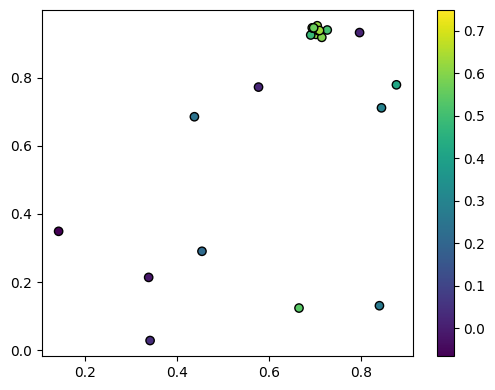

In [7]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)

plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap="viridis")

plt.colorbar()

plt.tight_layout()
plt.show()

## 4.3 Scatter plot - observations (3D)

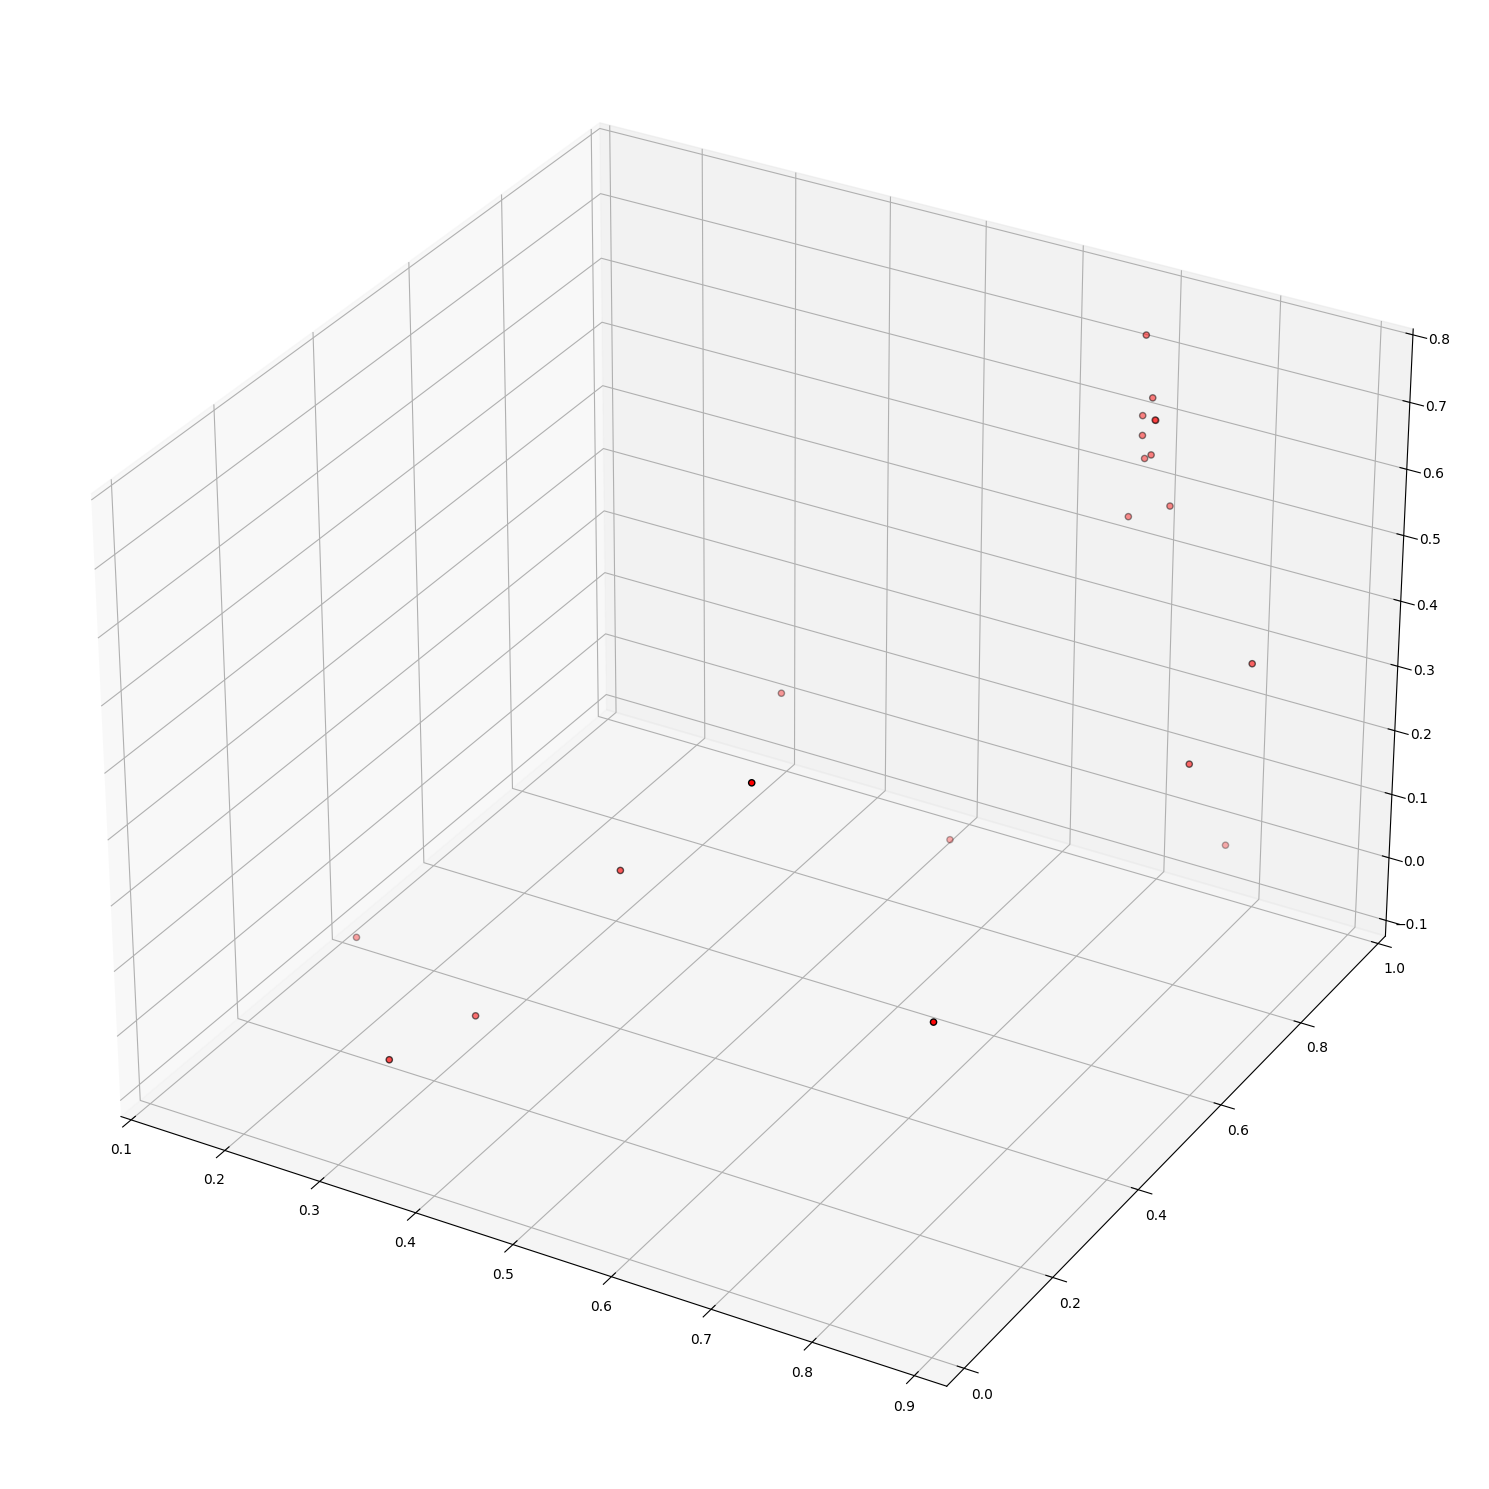

In [8]:
fig = plt.figure(figsize=(20, 15))

ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], y, c = 'red', edgecolors="k")

plt.tight_layout()
plt.show()

# 5. Surrogate Model

In [ ]:
#Define kernel used
kernel_best_Q2 =  ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=1.5, nu=1) + WhiteKernel(noise_level=1e-1, noise_level_bounds=(1e-6, 1e1))

#Initialize Gaussian Process Regressor
gp = GaussianProcessRegressor(kernel=kernel_best_Q2, n_restarts_optimizer=10, alpha=1e-6, normalize_y=True)

# Fit to data
gp.fit(X, y)

#Print the kernel to check if the value of optimized kernel is normal 
print("Optimized kernel:", gp.kernel_)

# 6. Acquisition function - UCB + Grid search

In [13]:
#define UCB
def ucb_gs(X_candidates, gp, kappa=1.0):
    mu, sigma = gp.predict(X_candidates, return_std=True)
    return mu + kappa * sigma

#Generate candidate points (dense grid in [0,1]^2)
x1_gs = np.linspace(0, 1, 5000)
x2_gs = np.linspace(0, 1, 5000)
X1_gs, X2_gs = np.meshgrid(x1_gs, x2_gs)
X_grid_gs = np.column_stack([X1_gs.ravel(), X2_gs.ravel()])

# Compute UCB
ucb_values_gs = ucb_gs(X_grid_gs, gp, kappa=0.5)

# Pick next query point (max UCB)
next_point_ucb_gs = X_grid_gs[np.argmax(ucb_values_gs)]
print("Next query point (by UCB):", next_point_ucb_gs)

Next query point (by UCB): [0.69693939 0.94818964]
